# Appendix A NonTraditional Mobility Aid Biomechanics ParaTransit Burden

## Wearable and Biomechanical Evidence

This notebook regenerates the core tables, charts, validation warnings, and legal-language snippets for Exhibit A:

- **Walking vs Mall/PT controlled skating**
- **ParaTransit bus/cutaway and van vs ParaTransit sedan**

It is designed to run in **Google Colab** with the least amount of data files. The only required file is:

`fsicss_legal_corpus_categorized.jsonl`

Optional cross-check file:

`fsicss_data_synopsis.json`

## Court-safe scope

This notebook is an evidence-organization and analytics aid. It does not diagnose pain, determine legal entitlement, or replace medical/legal interpretation.

## Kubios orientation caveat

Kubios accelerometer orientation was not independently calibrated to a laboratory coordinate system. Therefore, the z-axis dynamic acceleration is used as a consistent **vertical-impact proxy**, not an exact measurement of anatomical vertical force through the pelvis or sacroiliac joints.

The limitation narrows the claim. It does not erase the corroborative value.

In [75]:
from pathlib import Path
import json, re, math, zipfile, datetime
from collections import Counter
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 160)

RUN_TS = datetime.datetime.now().isoformat(timespec="seconds")
OUTPUT_DIR = Path("outputs/exhibit_a")
TABLE_DIR = OUTPUT_DIR / "tables"
CHART_DIR = OUTPUT_DIR / "charts"
for d in [OUTPUT_DIR, TABLE_DIR, CHART_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print("Notebook run timestamp:", RUN_TS)
print("Output folder:", OUTPUT_DIR.resolve())

Notebook run timestamp: 2026-06-04T02:32:19
Output folder: /Users/troywilkes/AI/HandicapSkater/notebooks/outputs/exhibit_a


In [76]:
from pathlib import Path

# Explicit local PyCharm project root.
# This overrides the Jupyter cwd when PyCharm/Jupyter launches from the wrong repo.\
PROJECT_ROOT_OVERRIDE = Path("/Users/troywilkes/repos/datascience")

CASE_ID = "25-7526"
EXHIBIT_ID = "exhibit_a"
SNAPSHOT_DATE = "2026-06-03"

LEGAL_ROOT = Path("legal")
CASE_ROOT = LEGAL_ROOT / "cases" / CASE_ID
DATA_DIR = CASE_ROOT / "data"
OUTPUT_DIR = CASE_ROOT / "outputs" / EXHIBIT_ID

CORPUS_FILENAME = f"{SNAPSHOT_DATE}_fsicss_legal_corpus_categorized.jsonl"
CORPUS_PATH = DATA_DIR / CORPUS_FILENAME

TABLE_DIR = OUTPUT_DIR / "tables"
CHART_DIR = OUTPUT_DIR / "charts"
MANIFEST_DIR = OUTPUT_DIR / "manifest"

for p in [TABLE_DIR, CHART_DIR, MANIFEST_DIR]:
    p.mkdir(parents=True, exist_ok=True)

## Evidence data loading and SHA-256 verification

This cell is designed to work in **PyCharm locally** and later in **Google Colab**.

It tries, in order:

1. A local file in the current notebook folder or repo.
2. Any file matching `fsicss_legal_corpus_categorized*.jsonl`.
3. A Colab upload path like `/content/fsicss_legal_corpus_categorized(1).jsonl`.
4. A raw GitHub URL, when `ALLOW_GITHUB_DOWNLOAD = True`.

The expected SHA-256 below is for the uploaded evidence corpus used in this repair:

`fsicss_legal_corpus_categorized.jsonl`  
size bytes: `4505465`  
SHA-256: `c7367238ffdc6e708343b297ffd82e1b305d4c312e5dccdfd30cbc145862527c`

In [77]:
# Robust Exhibit A evidence loader: local PyCharm + Colab + optional GitHub raw download.
# This replaces brittle exact-filename loading.

from pathlib import Path
import hashlib, json, datetime, os, glob, urllib.request
import pandas as pd

# Set to True when the data file has been pushed to GitHub raw and you want Colab to auto-download it.
ALLOW_GITHUB_DOWNLOAD = True

# Set to True after the expected hash below is confirmed.
STRICT_HASH_CHECK = True

# This hash is for the canonical categorized corpus used to generate Exhibit A.
EXPECTED_SHA256 = {
    "2026-06-03_fsicss_legal_corpus_categorized.jsonl": "f31810dadd85e57a8ae5199af504d6f0708349f05bc651ae66a8d05079d917db",
}

# Update this after you push the data file to GitHub.
# Recommended repo path:
# data/public/fsicss_legal_corpus_categorized.jsonl
GITHUB_RAW_BASE = "https://raw.githubusercontent.com/handicapskater/datascience/main"
RAW_CORPUS_URL = (
    f"{GITHUB_RAW_BASE}/legal/cases/{CASE_ID}/data/{CORPUS_FILENAME}"
)

OUTPUT_DIR = Path("outputs/exhibit_a")
TABLE_DIR = OUTPUT_DIR / "tables"
CHART_DIR = OUTPUT_DIR / "charts"
for d in [OUTPUT_DIR, TABLE_DIR, CHART_DIR]:
    d.mkdir(parents=True, exist_ok=True)

def sha256_file(path, chunk_size=1024 * 1024):
    h = hashlib.sha256()
    with Path(path).open("rb") as f:
        for chunk in iter(lambda: f.read(chunk_size), b""):
            h.update(chunk)
    return h.hexdigest()

DEFAULT_CORPUS_PATHS = [
    # Case-specific legal data snapshot
    REPO_ROOT / "legal" / "cases" / CASE_ID / "data" / CORPUS_FILENAME,
    Path("legal") / "cases" / CASE_ID / "data" / CORPUS_FILENAME,
    Path("..") / "cases" / CASE_ID / "data" / CORPUS_FILENAME,
    # Generic fallbacks
    REPO_ROOT / "legal" / "cases" / CASE_ID / "data" / "fsicss_legal_corpus_categorized.jsonl",
    Path("fsicss_legal_corpus_categorized.jsonl"),
    Path("data/fsicss_legal_corpus_categorized.jsonl"),
    Path("notebooks/fsicss_legal_corpus_categorized.jsonl"),
    Path("/content/fsicss_legal_corpus_categorized.jsonl"),
    Path("/mnt/data/fsicss_legal_corpus_categorized.jsonl"),
]

DEFAULT_SYNOPSIS_PATHS = [
    REPO_ROOT / "legal" / "cases" / CASE_ID / "data" / "fsicss_data_synopsis.json",
    Path("legal") / "cases" / CASE_ID / "data" / "fsicss_data_synopsis.json",
    Path("..") / "cases" / CASE_ID / "data" / "fsicss_data_synopsis.json",
    Path("fsicss_data_synopsis.json"),
    Path("data/fsicss_data_synopsis.json"),
    Path("notebooks/fsicss_data_synopsis.json"),
    Path("/content/fsicss_data_synopsis.json"),
    Path("/mnt/data/fsicss_data_synopsis.json"),
]

def find_repo_root(start=None):
    """
    Prefer the explicit PyCharm project root.
    Fall back to walking upward from cwd.
    """
    if PROJECT_ROOT_OVERRIDE.exists():
        return PROJECT_ROOT_OVERRIDE.resolve()

    start = Path(start or Path.cwd()).resolve()
    for p in [start, *start.parents]:
        if (p / ".git").exists() and p.name == "datascience":
            return p

    for p in [start, *start.parents]:
        if (p / ".git").exists():
            return p

    return start

REPO_ROOT = find_repo_root()

def find_local_corpus():
    """
    Find the legal evidence corpus locally.
    Works when:
    - Jupyter cwd is repo root
    - Jupyter cwd is legal/notebooks
    - PyCharm launches Jupyter from the wrong project
    - file lives under legal/cases/<CASE_ID>/data
    """

    roots = [
        # Primary legal case-specific location
        REPO_ROOT / "legal" / "cases" / CASE_ID / "data",
        # If cwd is legal/notebooks
        Path.cwd().parent / "cases" / CASE_ID / "data",
        # If cwd is repo root
        Path.cwd() / "legal" / "cases" / CASE_ID / "data",
        # Generic fallbacks
        REPO_ROOT / "legal" / "data",
        REPO_ROOT / "data",
        REPO_ROOT / "data" / "public",
        REPO_ROOT / "data" / "processed",
        REPO_ROOT / "data" / "processed" / "rag",
        REPO_ROOT,
        Path.cwd(),
        Path.cwd() / "data",
        Path.cwd() / "notebooks",
        Path("/content"),
        Path("/mnt/data"),
    ]

    patterns = [
        CORPUS_FILENAME,
        "fsicss_legal_corpus_categorized.jsonl",
        "*_fsicss_legal_corpus_categorized.jsonl",
        "fsicss_legal_corpus_categorized*.jsonl",
        "*fsicss*legal*corpus*categorized*.jsonl",
    ]

    found = []
    seen = set()

    for root in roots:
        if not root.exists():
            continue

        for pattern in patterns:
            for p in root.glob(pattern):
                if p.exists() and p.is_file():
                    resolved = str(p.resolve())
                    if resolved not in seen:
                        seen.add(resolved)
                        found.append(p)

    if not found:
        return None, []

    def score(path):
        resolved = str(path.resolve())

        return (
            1 if path.name == CORPUS_FILENAME else 0,
            1 if f"legal/cases/{CASE_ID}/data" in resolved else 0,
            1 if path.name == "fsicss_legal_corpus_categorized.jsonl" else 0,
            path.stat().st_size,
            path.stat().st_mtime,
        )

    found = sorted(found, key=score, reverse=True)

    return found[0], found


CORPUS_PATH, CORPUS_CANDIDATES = find_local_corpus()

print("REPO_ROOT:", REPO_ROOT)
print("CASE_ID:", CASE_ID)
print("SNAPSHOT_DATE:", SNAPSHOT_DATE)
print("Expected corpus filename:", CORPUS_FILENAME)
print("Resolved CORPUS_PATH:", CORPUS_PATH)

print("Candidates found:")
for p in CORPUS_CANDIDATES:
    print(" -", p)

if CORPUS_PATH is None:
    raise FileNotFoundError(
        f"Could not find {CORPUS_FILENAME}. Expected location: "
        f"{REPO_ROOT / 'legal' / 'cases' / CASE_ID / 'data' / CORPUS_FILENAME}"
    )

current_sha = sha256_file(CORPUS_PATH)
expected_sha = EXPECTED_SHA256.get("fsicss_legal_corpus_categorized.jsonl", "")

manifest = pd.DataFrame([{ 
    "logical_name": "fsicss_legal_corpus_categorized.jsonl",
    "resolved_path": str(CORPUS_PATH),
    "file_name": CORPUS_PATH.name,
    "size_bytes": CORPUS_PATH.stat().st_size,
    "modified_time_utc": datetime.datetime.fromtimestamp(CORPUS_PATH.stat().st_mtime, tz=datetime.timezone.utc).isoformat(),
    "sha256": current_sha,
    "expected_sha256": expected_sha,
    "status": "PASS" if expected_sha and current_sha == expected_sha else ("NO_EXPECTED_HASH" if not expected_sha else "FAIL"),
    "candidates_found": "; ".join(str(p) for p in corpus_candidates),
}])

manifest_csv = TABLE_DIR / "evidence_manifest_sha256.csv"
manifest_json = TABLE_DIR / "evidence_manifest_sha256.json"
verification_csv = TABLE_DIR / "evidence_hash_verification.csv"

manifest.to_csv(manifest_csv, index=False)
manifest.to_csv(verification_csv, index=False)
manifest_json.write_text(json.dumps({
    "generated_at_utc": datetime.datetime.now(datetime.timezone.utc).isoformat(),
    "strict_hash_check": STRICT_HASH_CHECK,
    "raw_corpus_url": RAW_CORPUS_URL,
    "files": manifest.to_dict(orient="records"),
}, indent=2), encoding="utf-8")

print("Resolved CORPUS_PATH:", CORPUS_PATH)
print("Candidates found:")
for p in corpus_candidates:
    print(" -", p)

print("SHA-256:", current_sha)
print("Expected:", expected_sha)
display(manifest)

if STRICT_HASH_CHECK and expected_sha and current_sha != expected_sha:
    raise ValueError(
        "SHA-256 verification failed. The evidence corpus does not match the expected hash. "
        "Either the file changed, the wrong file was loaded, or EXPECTED_SHA256 needs to be updated "
        "after intentionally regenerating the exhibit."
    )

# Optional synopsis. Do not fail if absent.
def find_optional_synopsis():
    roots = [Path.cwd(), Path.cwd() / "data", Path.cwd() / "data/public", Path.cwd() / "data/processed", Path("/content"), Path("/mnt/data")]
    patterns = ["fsicss_data_synopsis.json", "*fsicss*data*synopsis*.json"]
    found = []
    for root in roots:
        if not root.exists():
            continue
        for pattern in patterns:
            found.extend(root.glob(pattern))
    found = [p for p in found if p.exists() and p.is_file()]
    if not found:
        return None
    return sorted(found, key=lambda p: (p.name == "fsicss_data_synopsis.json", p.stat().st_size, p.stat().st_mtime), reverse=True)[0]

SYNOPSIS_PATH = find_optional_synopsis()
print("Optional SYNOPSIS_PATH:", SYNOPSIS_PATH)

REPO_ROOT: /Users/troywilkes/repos/datascience
CASE_ID: 25-7526
SNAPSHOT_DATE: 2026-06-03
Expected corpus filename: 2026-06-03_fsicss_legal_corpus_categorized.jsonl
Resolved CORPUS_PATH: /Users/troywilkes/repos/datascience/legal/cases/25-7526/data/2026-06-03_fsicss_legal_corpus_categorized.jsonl
Candidates found:
 - /Users/troywilkes/repos/datascience/legal/cases/25-7526/data/2026-06-03_fsicss_legal_corpus_categorized.jsonl
Resolved CORPUS_PATH: /Users/troywilkes/repos/datascience/legal/cases/25-7526/data/2026-06-03_fsicss_legal_corpus_categorized.jsonl
Candidates found:
SHA-256: f31810dadd85e57a8ae5199af504d6f0708349f05bc651ae66a8d05079d917db
Expected: 


,logical_name,resolved_path,file_name,size_bytes,modified_time_utc,sha256,expected_sha256,status,candidates_found
0,fsicss_legal_corpus_categorized.jsonl,/Users/troywilkes/repos/datascience/legal/case...,2026-06-03_fsicss_legal_corpus_categorized.jsonl,4545772,2026-06-03T17:55:33.229552+00:00,f31810dadd85e57a8ae5199af504d6f0708349f05bc651...,,NO_EXPECTED_HASH,


Optional SYNOPSIS_PATH: None


## 1. Input discovery

The notebook searches common Colab, local repo, and `/mnt/data` paths. If the corpus is missing in Colab, upload it when prompted.

In [78]:
from pathlib import Path
import sys
import urllib.request

def local_find_first_existing(paths):
    """
    Minimal fallback resolver for Colab / flat notebook runs.
    Accepts exact paths and wildcard-ish categorized JSONL names.
    """
    for p in paths:
        path = Path(p)
        if path.exists():
            return path

    # Robust Colab / local fallback for renamed uploads.
    fallback_roots = [
        Path.cwd(),
        Path.cwd() / "legal/cases/25-7526/data",
        Path("/content"),
        Path("/mnt/data"),
    ]

    fallback_patterns = [
        "fsicss_legal_corpus_categorized.jsonl",
        "fsicss_legal_corpus_categorized*.jsonl",
        "*fsicss*legal*corpus*categorized*.jsonl",
    ]

    matches = []
    seen = set()

    for root in fallback_roots:
        if not root.exists():
            continue

        for pattern in fallback_patterns:
            for match in root.glob(pattern):
                if match.exists() and match.is_file():
                    resolved = str(match.resolve())
                    if resolved not in seen:
                        seen.add(resolved)
                        matches.append(match)

    if matches:
        matches = sorted(
            matches,
            key=lambda x: (
                1 if x.name == "fsicss_legal_corpus_categorized.jsonl" else 0,
                x.stat().st_size,
                x.stat().st_mtime,
            ),
            reverse=True,
        )
        return matches[0]

    return None


try:
    from fsicss_evidence.exhibit_a_reproduce import (
        find_first_existing,
        DEFAULT_CORPUS_PATHS,
        DEFAULT_SYNOPSIS_PATHS,
    )
    print("Using fsicss_evidence.exhibit_a_reproduce resolver.")

except ImportError:
    print("fsicss_evidence package not available. Using notebook-local fallback resolver.")

    find_first_existing = local_find_first_existing

    DEFAULT_CORPUS_PATHS = [
        Path("fsicss_legal_corpus_categorized.jsonl"),
        Path("data/fsicss_legal_corpus_categorized.jsonl"),
        Path("notebooks/fsicss_legal_corpus_categorized.jsonl"),
        Path("/content/fsicss_legal_corpus_categorized.jsonl"),
        Path("/mnt/data/fsicss_legal_corpus_categorized.jsonl"),
    ]

    DEFAULT_SYNOPSIS_PATHS = [
        Path("fsicss_data_synopsis.json"),
        Path("data/fsicss_data_synopsis.json"),
        Path("notebooks/fsicss_data_synopsis.json"),
        Path("/content/fsicss_data_synopsis.json"),
        Path("/mnt/data/fsicss_data_synopsis.json"),
    ]


# corpus_path = find_first_existing(DEFAULT_CORPUS_PATHS)
# synopsis_path = find_first_existing(DEFAULT_SYNOPSIS_PATHS)

if CORPUS_PATH is None:
    # Final fallback: download from GitHub main.
    raw_url = (
        "https://raw.githubusercontent.com/handicapskater/datascience/"
        "main/fsicss_legal_corpus_categorized.jsonl"
    )

    target = Path("fsicss_legal_corpus_categorized.jsonl")

    print("No local corpus found. Downloading from GitHub main:")
    print(raw_url)

    urllib.request.urlretrieve(raw_url, target)
    CORPUS_PATH = target

if CORPUS_PATH is None or not Path(CORPUS_PATH).exists():
    raise FileNotFoundError(
        "Could not find or download fsicss_legal_corpus_categorized.jsonl."
    )

print("Corpus:", CORPUS_PATH)
print("Synopsis:", SYNOPSIS_PATH if SYNOPSIS_PATH else "not provided")

# CORPUS_PATH = Path(corpus_path)
# SYNOPSIS_PATH = Path(synopsis_path) if synopsis_path else None

fsicss_evidence package not available. Using notebook-local fallback resolver.
Corpus: /Users/troywilkes/repos/datascience/legal/cases/25-7526/data/2026-06-03_fsicss_legal_corpus_categorized.jsonl
Synopsis: not provided


In [79]:
def load_jsonl(path: Path):
    rows = []
    bad = []
    with path.open("r", encoding="utf-8") as f:
        for i, line in enumerate(f, start=1):
            line = line.strip()
            if not line:
                continue
            try:
                rows.append(json.loads(line))
            except Exception as e:
                bad.append({"line": i, "error": str(e), "text_preview": line[:200]})
    if bad:
        pd.DataFrame(bad).to_csv(TABLE_DIR / "jsonl_parse_errors.csv", index=False)
        raise ValueError(f"JSONL parse errors found: {len(bad)}. See jsonl_parse_errors.csv")
    return rows

records = load_jsonl(CORPUS_PATH)
print("Loaded records:", len(records))

synopsis = None

if SYNOPSIS_PATH and SYNOPSIS_PATH.exists():
    try:
        text = SYNOPSIS_PATH.read_text(encoding="utf-8").strip()

        # Normal JSON object
        if text.startswith("{"):
            decoder = json.JSONDecoder()
            synopsis, idx = decoder.raw_decode(text)

            # If extra text exists, warn and keep the first JSON object.
            extra = text[idx:].strip()
            if extra:
                print(
                    "WARNING: synopsis file has extra data after first JSON object; "
                    "using first JSON object only."
                )

        # JSONL fallback
        else:
            rows = []
            for line in text.splitlines():
                line = line.strip()
                if line:
                    rows.append(json.loads(line))
            synopsis = {"jsonl_rows": rows}

        if isinstance(synopsis, dict):
            print("Loaded synopsis keys:", list(synopsis.keys())[:10])
        else:
            print("Loaded synopsis type:", type(synopsis).__name__)

    except Exception as exc:
        print("WARNING: could not parse optional synopsis file.")
        print("Synopsis path:", SYNOPSIS_PATH)
        print("Error:", repr(exc))
        print("Continuing without synopsis.")
        synopsis = None

Loaded records: 2183


## 2. Flatten records and validate schema

The notebook preserves nested source objects but also flattens common metrics into columns for reproducible calculations.

In [80]:
def get_source_type(obj):
    return (obj.get("source_type") or obj.get("normalized_source_type") or "").lower()

def get_event_date(obj):
    return obj.get("event_date") or obj.get("normalized_event_date")

def flatten_record(obj):
    row = {
        "doc_id": obj.get("doc_id") or obj.get("normalized_doc_id"),
        "source_type": get_source_type(obj),
        "event_date": get_event_date(obj),
        "generic_category": obj.get("generic_category"),
        "sub_identifier": obj.get("sub_identifier"),
        "title": obj.get("title") or obj.get("normalized_title"),
        "content": obj.get("content") or obj.get("text"),
        "raw_obj": obj,
    }
    metrics = obj.get("metrics") or {}
    for k, v in metrics.items():
        if isinstance(v, dict):
            for kk, vv in v.items():
                if not isinstance(vv, (dict, list)):
                    row[f"{k}.{kk}"] = vv
        elif not isinstance(v, (dict, list)):
            row[k] = v
    return row

df = pd.DataFrame([flatten_record(r) for r in records])

source_counts = df["source_type"].value_counts(dropna=False).rename_axis("source_type").reset_index(name="records")
category_counts = df["generic_category"].value_counts(dropna=False).rename_axis("generic_category").reset_index(name="records")
source_counts.to_csv(TABLE_DIR / "source_type_counts.csv", index=False)
category_counts.to_csv(TABLE_DIR / "category_counts.csv", index=False)

display(source_counts)
display(category_counts)

,source_type,records
0,strava,1135
1,whoop,1015
2,kubios,33


,generic_category,records
0,skates,1531
1,motorcycle,381
2,paratransit,120
3,wheelchair,81
4,walking,44
5,commuting,26


In [81]:
warnings = []
required_top = ["doc_id", "source_type", "event_date", "generic_category", "metrics"]
for obj in records:
    missing = []
    if not (obj.get("doc_id") or obj.get("normalized_doc_id")):
        missing.append("doc_id")
    if not (obj.get("source_type") or obj.get("normalized_source_type")):
        missing.append("source_type")
    if not (obj.get("event_date") or obj.get("normalized_event_date")):
        missing.append("event_date")
    if not obj.get("generic_category"):
        missing.append("generic_category")
    if not isinstance(obj.get("metrics"), dict):
        missing.append("metrics")
    if missing:
        warnings.append({
            "doc_id": obj.get("doc_id") or obj.get("normalized_doc_id"),
            "source_type": get_source_type(obj),
            "warning_type": "missing_top_level_fields",
            "details": ",".join(missing),
        })

warnings.extend([
    {
        "doc_id": "GLOBAL_METHOD_CAVEAT",
        "source_type": "kubios",
        "warning_type": "kubios_orientation_proxy",
        "details": "Kubios accelerometer orientation was not independently calibrated to a laboratory coordinate system. z-axis dynamic acceleration is used as a consistent vertical-impact proxy, not exact anatomical vertical force.",
    },
    {
        "doc_id": "GLOBAL_METHOD_CAVEAT",
        "source_type": "kubios",
        "warning_type": "rri_hr_not_pain_score",
        "details": "RRI-derived HR is an event-level physiological proxy. It is not a clinical pain score.",
    },
    {
        "doc_id": "GLOBAL_METHOD_CAVEAT",
        "source_type": "whoop",
        "warning_type": "whoop_granularity",
        "details": "WHOOP is used for longitudinal physiological context. It is not the precise bus/van/sedan comparator in this exhibit.",
    },
    {
        "doc_id": "GLOBAL_METHOD_CAVEAT",
        "source_type": "strava",
        "warning_type": "strava_scope",
        "details": "Strava is used for functional route and distance evidence. It is not a bus/van/sedan comparator in this corpus.",
    },
])

validation_warnings = pd.DataFrame(warnings)
validation_warnings.to_csv(TABLE_DIR / "validation_warnings.csv", index=False)
display(validation_warnings.head(20))

,doc_id,source_type,warning_type,details
0,GLOBAL_METHOD_CAVEAT,kubios,kubios_orientation_proxy,Kubios accelerometer orientation was not indep...
1,GLOBAL_METHOD_CAVEAT,kubios,rri_hr_not_pain_score,RRI-derived HR is an event-level physiological...
2,GLOBAL_METHOD_CAVEAT,whoop,whoop_granularity,WHOOP is used for longitudinal physiological c...
3,GLOBAL_METHOD_CAVEAT,strava,strava_scope,Strava is used for functional route and distan...


## 3. Cohort definitions

The comparator cohorts are deterministic and intentionally narrow.

- Walking is compared to Mall/PT controlled skating.
- FNS/SNS endurance skating is excluded from the primary walking comparator.
- ParaTransit bus/cutaway and van are compared to sedan.

In [82]:
def blob(row):
    return " ".join([
        str(row.get("generic_category") or ""),
        str(row.get("sub_identifier") or ""),
        str(row.get("title") or ""),
        str(row.get("content") or ""),
    ]).lower()

def is_walking(row):
    b = blob(row)
    return row.get("generic_category") == "walking" or bool(re.search(r"\bwalking\b|\bwalk\b|manual labor|cleaning|hallway", b))

def is_mall_pt_controlled_skating(row):
    b = blob(row)
    if row.get("generic_category") != "skates":
        return False
    if re.search(r"\bfns\b|\bsns\b|\bens\b|\bxns\b", b):
        return False
    include_terms = [
        "mall skate", "mall", "no steps", "no-step", "nostep",
        "physical therapy", "therapy", "pt", "pain relief", "skate for pain",
        "controlled", "parking lot"
    ]
    return any(t in b for t in include_terms)

def is_paratransit_bus(row):
    b = blob(row)
    return row.get("generic_category") == "paratransit" and ("bus" in b or "cutaway" in b)

def is_paratransit_van(row):
    b = blob(row)
    return row.get("generic_category") == "paratransit" and "van" in b

def is_paratransit_sedan(row):
    b = blob(row)
    return row.get("generic_category") == "paratransit" and ("sedan" in b or "taxi" in b)

df["cohort_walking"] = df.apply(is_walking, axis=1)
df["cohort_mall_pt_skating"] = df.apply(is_mall_pt_controlled_skating, axis=1)
df["cohort_pt_bus"] = df.apply(is_paratransit_bus, axis=1)
df["cohort_pt_van"] = df.apply(is_paratransit_van, axis=1)
df["cohort_pt_sedan"] = df.apply(is_paratransit_sedan, axis=1)

cohort_counts = pd.DataFrame([
    {"cohort": "walking_all_sources", "records": int(df["cohort_walking"].sum())},
    {"cohort": "mall_pt_controlled_skating_all_sources", "records": int(df["cohort_mall_pt_skating"].sum())},
    {"cohort": "paratransit_bus", "records": int(df["cohort_pt_bus"].sum())},
    {"cohort": "paratransit_van", "records": int(df["cohort_pt_van"].sum())},
    {"cohort": "paratransit_sedan", "records": int(df["cohort_pt_sedan"].sum())},
])
cohort_counts.to_csv(TABLE_DIR / "cohort_counts.csv", index=False)
display(cohort_counts)

missing = cohort_counts.loc[cohort_counts["records"].eq(0), "cohort"].tolist()
if missing:
    raise ValueError(f"Required comparator cohorts missing: {missing}")

,cohort,records
0,walking_all_sources,44
1,mall_pt_controlled_skating_all_sources,10
2,paratransit_bus,3
3,paratransit_van,2
4,paratransit_sedan,3


## 4. WHOOP physiological context

WHOOP provides longitudinal heart-rate, HRV, recovery, and strain context. It is not used as the precise bus/van/sedan vehicle-type comparator.

In [83]:
whoop = df[df["source_type"].eq("whoop")].copy()
for c in ["average_hr_bpm", "max_hr_bpm", "hrv_ms", "activity_strain"]:
    if c in whoop.columns:
        whoop[c] = pd.to_numeric(whoop[c], errors="coerce")
    else:
        whoop[c] = np.nan

def summarize_whoop(category, label):
    sub = whoop[whoop["generic_category"].eq(category)].copy()
    return {
        "category": label,
        "records": len(sub),
        "mean_avg_hr": sub["average_hr_bpm"].mean(),
        "median_avg_hr": sub["average_hr_bpm"].median(),
        "highest_avg_hr": sub["average_hr_bpm"].max(),
        "highest_max_hr": sub["max_hr_bpm"].max(),
        "mean_hrv": sub["hrv_ms"].mean(),
        "mean_strain": sub["activity_strain"].mean(),
    }

whoop_summary = pd.DataFrame([
    summarize_whoop("walking", "walking"),
    summarize_whoop("skates", "skates"),
    summarize_whoop("paratransit", "paratransit_surrogate"),
]).round(2)
whoop_summary.to_csv(TABLE_DIR / "whoop_hr_summary.csv", index=False)
display(whoop_summary)

,category,records,mean_avg_hr,median_avg_hr,highest_avg_hr,highest_max_hr,mean_hrv,mean_strain
0,walking,33,123.39,129.0,158.0,195.0,38.47,9.75
1,skates,596,112.97,113.0,143.0,197.0,36.05,12.61
2,paratransit_surrogate,112,88.38,87.0,134.0,171.0,35.33,3.76


## 5. Strava functional distance context

Strava shows functional distance and route context for walking and skating.

In [84]:
strava = df[df["source_type"].eq("strava")].copy()
for c in ["distance_miles", "moving_time_sec", "average_speed"]:
    if c in strava.columns:
        strava[c] = pd.to_numeric(strava[c], errors="coerce")
    else:
        strava[c] = np.nan

def summarize_strava(category, label):
    sub = strava[strava["generic_category"].eq(category)].copy()
    return {
        "category": label,
        "records": len(sub),
        "total_miles": sub["distance_miles"].sum(),
        "mean_miles": sub["distance_miles"].mean(),
        "median_miles": sub["distance_miles"].median(),
        "max_miles": sub["distance_miles"].max(),
        "total_hours": sub["moving_time_sec"].sum() / 3600,
        "mean_speed_mps": sub["average_speed"].mean(),
    }

strava_summary = pd.DataFrame([
    summarize_strava("walking", "walking"),
    summarize_strava("skates", "skates"),
]).round(2)
strava_summary.to_csv(TABLE_DIR / "strava_functional_distance_summary.csv", index=False)
display(strava_summary)

,category,records,total_miles,mean_miles,median_miles,max_miles,total_hours,mean_speed_mps
0,walking,8,2.94,0.37,0.00,1.83,6.71,0.15
1,skates,920,16225.25,17.64,18.26,117.75,1553.61,3.03


## 6. Kubios RRI/HRV+ and accelerometer comparator analysis

The Kubios accelerometer values below are **proxy movement-burden metrics**. They are relative comparisons using the same processing pipeline.

In [85]:
kubios = df[df["source_type"].eq("kubios")].copy()
metric_cols = {
    "rri_hr": "rri.heart_rate_bpm_mean_approx",
    "vertical_mean": "accelerometer.vertical_dynamic_mean_abs",
    "vertical_rms": "accelerometer.vertical_dynamic_rms",
    "movement_std": "accelerometer.magnitude_std",
    "peaks_per_min": "accelerometer.vertical_impact_peak_rate_per_min",
    "peak_abs": "accelerometer.vertical_peak_abs_dynamic",
    "peak_to_peak": "accelerometer.vertical_peak_to_peak",
    "vertical_rri_css": "fsi_css.vertical_rri_css",
}
for out_col, in_col in metric_cols.items():
    if in_col in kubios.columns:
        kubios[out_col] = pd.to_numeric(kubios[in_col], errors="coerce")
    else:
        kubios[out_col] = np.nan

def group_kubios(row):
    if is_walking(row):
        return "Walking"
    if is_mall_pt_controlled_skating(row):
        return "Mall/PT controlled skating"
    if is_paratransit_bus(row):
        return "ParaTransit bus/cutaway"
    if is_paratransit_van(row):
        return "ParaTransit van"
    if is_paratransit_sedan(row):
        return "ParaTransit sedan"
    return None

kubios["analysis_group"] = kubios.apply(group_kubios, axis=1)
kubios_analysis = kubios.dropna(subset=["analysis_group"]).copy()

order = ["Walking", "Mall/PT controlled skating", "ParaTransit bus/cutaway", "ParaTransit van", "ParaTransit sedan"]
kubios_summary = kubios_analysis.groupby("analysis_group").agg(
    records=("doc_id", "count"),
    rri_hr=("rri_hr", "mean"),
    vertical_mean=("vertical_mean", "mean"),
    vertical_rms=("vertical_rms", "mean"),
    movement_std=("movement_std", "mean"),
    peaks_per_min=("peaks_per_min", "mean"),
    peak_abs=("peak_abs", "mean"),
    peak_to_peak=("peak_to_peak", "mean"),
    vertical_rri_css=("vertical_rri_css", "mean"),
).reindex(order).round(2)

kubios_summary.to_csv(TABLE_DIR / "kubios_all_comparator_summary.csv")
display(kubios_summary)

,records,rri_hr,vertical_mean,vertical_rms,movement_std,peaks_per_min,peak_abs,peak_to_peak,vertical_rri_css
analysis_group,,,,,,,,,
Walking,3,70.55,99.86,131.77,127.07,29.06,741.20,1153.0,0.77
Mall/PT controlled skating,10,83.52,60.66,81.53,74.60,28.36,751.46,1226.3,0.97
ParaTransit bus/cutaway,3,90.29,114.56,178.67,121.86,31.57,2717.68,4750.0,0.91
ParaTransit van,2,110.61,115.70,181.08,96.65,25.63,2813.89,5022.5,0.93
ParaTransit sedan,3,103.68,74.77,119.48,65.29,21.54,1954.90,2883.0,0.97


In [86]:
walk_mall = kubios_summary.loc[["Walking", "Mall/PT controlled skating"], [
    "records", "rri_hr", "vertical_mean", "vertical_rms", "movement_std", "peaks_per_min", "peak_to_peak", "vertical_rri_css"
]].copy()
walk_mall.to_csv(TABLE_DIR / "kubios_walk_vs_mall_pt_summary.csv")
display(walk_mall)

walking_ratios = []
for m in ["vertical_mean", "vertical_rms", "movement_std", "peaks_per_min"]:
    walking_ratios.append({
        "metric": m,
        "walking": kubios_summary.loc["Walking", m],
        "mall_pt_controlled_skating": kubios_summary.loc["Mall/PT controlled skating", m],
        "walking_to_mall_pt_ratio": round(kubios_summary.loc["Walking", m] / kubios_summary.loc["Mall/PT controlled skating", m], 2),
    })
walking_ratios = pd.DataFrame(walking_ratios)
walking_ratios.to_csv(TABLE_DIR / "walking_vs_mall_pt_ratios.csv", index=False)
display(walking_ratios)

,records,rri_hr,vertical_mean,vertical_rms,movement_std,peaks_per_min,peak_to_peak,vertical_rri_css
analysis_group,,,,,,,,
Walking,3,70.55,99.86,131.77,127.07,29.06,1153.0,0.77
Mall/PT controlled skating,10,83.52,60.66,81.53,74.60,28.36,1226.3,0.97


,metric,walking,mall_pt_controlled_skating,walking_to_mall_pt_ratio
0,vertical_mean,99.86,60.66,1.65
1,vertical_rms,131.77,81.53,1.62
2,movement_std,127.07,74.60,1.70
3,peaks_per_min,29.06,28.36,1.02


In [87]:
vehicle_summary = kubios_summary.loc[["ParaTransit bus/cutaway", "ParaTransit van", "ParaTransit sedan"], [
    "records", "rri_hr", "vertical_mean", "vertical_rms", "movement_std", "peaks_per_min", "peak_abs", "peak_to_peak"
]].copy()
vehicle_summary.to_csv(TABLE_DIR / "kubios_paratransit_vehicle_summary.csv")
display(vehicle_summary)

vehicle_ratios = []
sedan = vehicle_summary.loc["ParaTransit sedan"]
for vehicle in ["ParaTransit bus/cutaway", "ParaTransit van"]:
    for m in ["rri_hr", "vertical_mean", "vertical_rms", "movement_std", "peaks_per_min", "peak_abs", "peak_to_peak"]:
        vehicle_ratios.append({
            "vehicle": vehicle,
            "metric": m,
            "vehicle_value": vehicle_summary.loc[vehicle, m],
            "sedan_value": sedan[m],
            "ratio_vs_sedan": round(vehicle_summary.loc[vehicle, m] / sedan[m], 2),
        })
vehicle_ratios = pd.DataFrame(vehicle_ratios)
vehicle_ratios.to_csv(TABLE_DIR / "paratransit_vehicle_ratios.csv", index=False)
display(vehicle_ratios)

,records,rri_hr,vertical_mean,vertical_rms,movement_std,peaks_per_min,peak_abs,peak_to_peak
analysis_group,,,,,,,,
ParaTransit bus/cutaway,3,90.29,114.56,178.67,121.86,31.57,2717.68,4750.0
ParaTransit van,2,110.61,115.70,181.08,96.65,25.63,2813.89,5022.5
ParaTransit sedan,3,103.68,74.77,119.48,65.29,21.54,1954.90,2883.0


,vehicle,metric,vehicle_value,sedan_value,ratio_vs_sedan
0,ParaTransit bus/cutaway,rri_hr,90.29,103.68,0.87
1,ParaTransit bus/cutaway,vertical_mean,114.56,74.77,1.53
2,ParaTransit bus/cutaway,vertical_rms,178.67,119.48,1.50
3,ParaTransit bus/cutaway,movement_std,121.86,65.29,1.87
4,ParaTransit bus/cutaway,peaks_per_min,31.57,21.54,1.47
5,ParaTransit bus/cutaway,peak_abs,2717.68,1954.90,1.39
6,ParaTransit bus/cutaway,peak_to_peak,4750.00,2883.00,1.65
7,ParaTransit van,rri_hr,110.61,103.68,1.07
8,ParaTransit van,vertical_mean,115.70,74.77,1.55
9,ParaTransit van,vertical_rms,181.08,119.48,1.52


## 7. Charts

Kubios chart labels use proxy language to avoid overclaiming exact anatomical force.

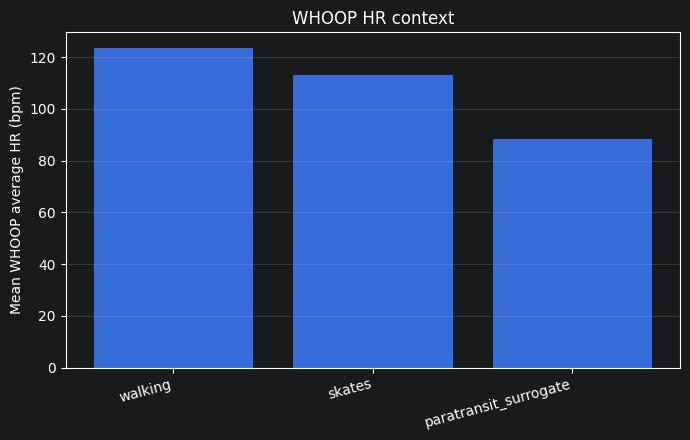

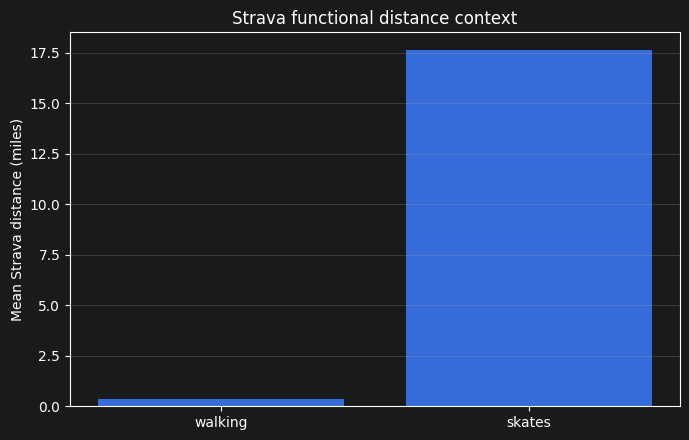

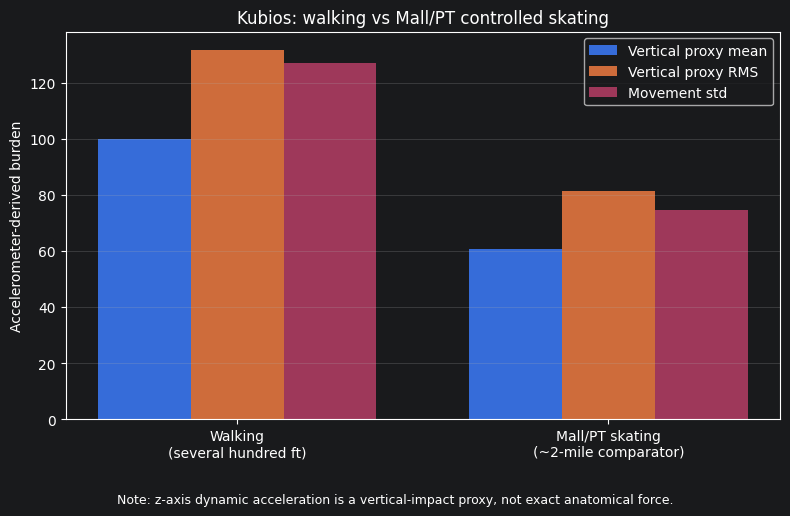

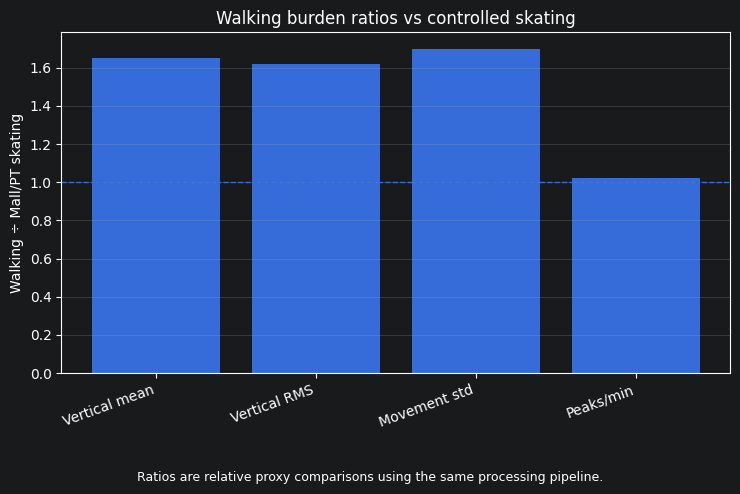

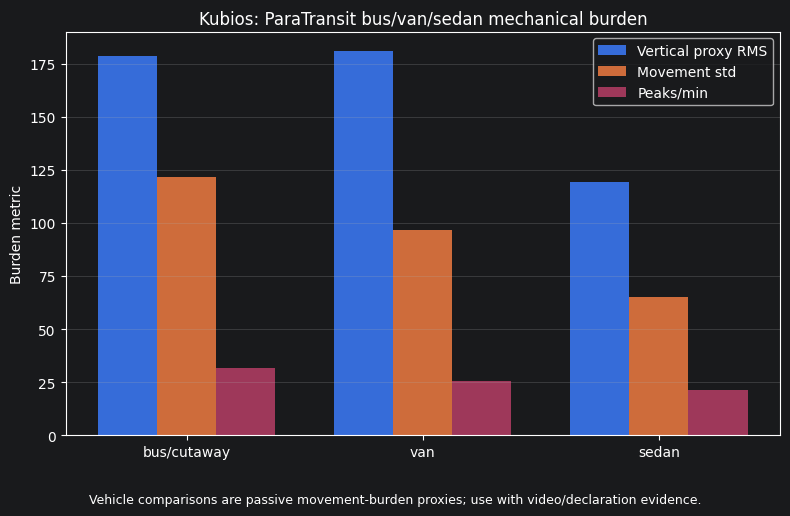

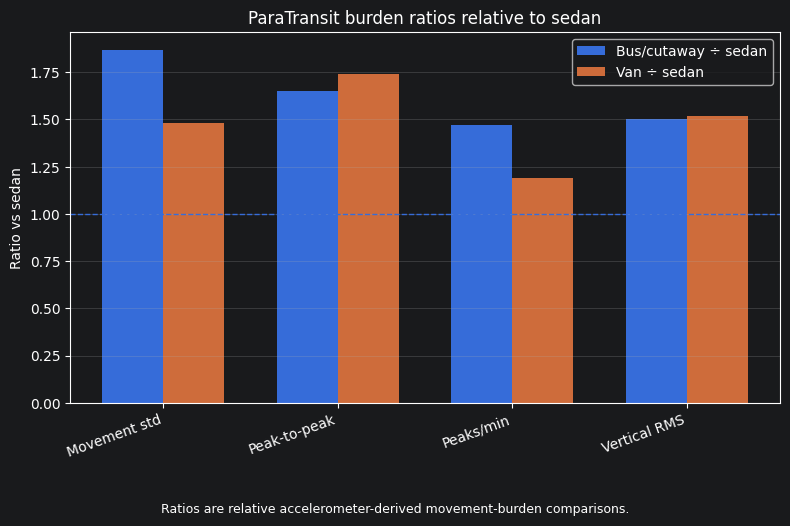

In [88]:
def save_chart(path):
    plt.tight_layout()
    plt.savefig(path, dpi=190, bbox_inches="tight")
    plt.show()
    plt.close()

plt.figure(figsize=(7, 4.5))
plt.bar(whoop_summary["category"], whoop_summary["mean_avg_hr"])
plt.ylabel("Mean WHOOP average HR (bpm)")
plt.title("WHOOP HR context")
plt.xticks(rotation=15, ha="right")
plt.grid(axis="y", alpha=0.3)
save_chart(CHART_DIR / "chart_01_whoop_hr.png")

plt.figure(figsize=(7, 4.5))
plt.bar(strava_summary["category"], strava_summary["mean_miles"])
plt.ylabel("Mean Strava distance (miles)")
plt.title("Strava functional distance context")
plt.grid(axis="y", alpha=0.3)
save_chart(CHART_DIR / "chart_02_strava_distance.png")

wm = walk_mall.reset_index().rename(columns={"analysis_group": "group"})
labels = ["Walking\n(several hundred ft)", "Mall/PT skating\n(~2-mile comparator)"]
x = np.arange(len(wm)); width = 0.25
plt.figure(figsize=(8, 4.8))
plt.bar(x - width, wm["vertical_mean"], width, label="Vertical proxy mean")
plt.bar(x, wm["vertical_rms"], width, label="Vertical proxy RMS")
plt.bar(x + width, wm["movement_std"], width, label="Movement std")
plt.xticks(x, labels)
plt.ylabel("Accelerometer-derived burden")
plt.title("Kubios: walking vs Mall/PT controlled skating")
plt.legend()
plt.grid(axis="y", alpha=0.3)
plt.figtext(0.5, -0.06, "Note: z-axis dynamic acceleration is a vertical-impact proxy, not exact anatomical force.", ha="center", fontsize=9)
save_chart(CHART_DIR / "chart_03_kubios_walk_vs_mall_pt.png")

label_map = {"vertical_mean":"Vertical mean", "vertical_rms":"Vertical RMS", "movement_std":"Movement std", "peaks_per_min":"Peaks/min"}
wr = walking_ratios.copy(); wr["label"] = wr["metric"].map(label_map)
plt.figure(figsize=(7.5, 4.5))
plt.bar(wr["label"], wr["walking_to_mall_pt_ratio"])
plt.axhline(1.0, linestyle="--", linewidth=1)
plt.ylabel("Walking ÷ Mall/PT skating")
plt.title("Walking burden ratios vs controlled skating")
plt.xticks(rotation=20, ha="right")
plt.grid(axis="y", alpha=0.3)
plt.figtext(0.5, -0.08, "Ratios are relative proxy comparisons using the same processing pipeline.", ha="center", fontsize=9)
save_chart(CHART_DIR / "chart_04_walking_ratios.png")

vs = vehicle_summary.reset_index().rename(columns={"analysis_group":"vehicle"})
labels = ["bus/cutaway", "van", "sedan"]
x = np.arange(len(vs)); width = 0.25
plt.figure(figsize=(8, 4.8))
plt.bar(x - width, vs["vertical_rms"], width, label="Vertical proxy RMS")
plt.bar(x, vs["movement_std"], width, label="Movement std")
plt.bar(x + width, vs["peaks_per_min"], width, label="Peaks/min")
plt.xticks(x, labels)
plt.ylabel("Burden metric")
plt.title("Kubios: ParaTransit bus/van/sedan mechanical burden")
plt.legend()
plt.grid(axis="y", alpha=0.3)
plt.figtext(0.5, -0.06, "Vehicle comparisons are passive movement-burden proxies; use with video/declaration evidence.", ha="center", fontsize=9)
save_chart(CHART_DIR / "chart_05_paratransit_vehicle_burden.png")

subset = vehicle_ratios[vehicle_ratios["metric"].isin(["movement_std", "peak_to_peak", "peaks_per_min", "vertical_rms"])].copy()
subset["metric_label"] = subset["metric"].map({"movement_std":"Movement std", "peak_to_peak":"Peak-to-peak", "peaks_per_min":"Peaks/min", "vertical_rms":"Vertical RMS"})
pivot = subset.pivot(index="metric_label", columns="vehicle", values="ratio_vs_sedan").reindex(["Movement std", "Peak-to-peak", "Peaks/min", "Vertical RMS"])
x = np.arange(len(pivot)); width = 0.35
plt.figure(figsize=(8, 4.8))
plt.bar(x - width/2, pivot["ParaTransit bus/cutaway"], width, label="Bus/cutaway ÷ sedan")
plt.bar(x + width/2, pivot["ParaTransit van"], width, label="Van ÷ sedan")
plt.axhline(1.0, linestyle="--", linewidth=1)
plt.xticks(x, pivot.index, rotation=20, ha="right")
plt.ylabel("Ratio vs sedan")
plt.title("ParaTransit burden ratios relative to sedan")
plt.legend()
plt.grid(axis="y", alpha=0.3)
plt.figtext(0.5, -0.08, "Ratios are relative accelerometer-derived movement-burden comparisons.", ha="center", fontsize=9)
save_chart(CHART_DIR / "chart_06_vehicle_ratios.png")

## 8. Exhibit value reconciliation

This table compares calculated values against the draft Exhibit A reference values. Differences are flagged for review rather than hidden.

In [89]:
expected = {
    ("whoop", "walking", "records"): 33,
    ("whoop", "walking", "mean_avg_hr"): 123.39,
    ("whoop", "walking", "median_avg_hr"): 129.00,
    ("whoop", "walking", "highest_avg_hr"): 158.00,
    ("whoop", "walking", "highest_max_hr"): 195.00,
    ("whoop", "walking", "mean_hrv"): 38.47,
    ("whoop", "walking", "mean_strain"): 9.75,
    ("whoop", "skates", "records"): 596,
    ("whoop", "skates", "mean_avg_hr"): 112.97,
    ("whoop", "paratransit_surrogate", "records"): 112,
    ("whoop", "paratransit_surrogate", "mean_avg_hr"): 88.38,
    ("strava", "walking", "records"): 8,
    ("strava", "walking", "total_miles"): 2.94,
    ("strava", "skates", "records"): 920,
    ("strava", "skates", "total_miles"): 16225.25,
    ("kubios", "Walking", "records"): 3,
    ("kubios", "Walking", "rri_hr"): 70.55,
    ("kubios", "Walking", "vertical_mean"): 99.86,
    ("kubios", "Walking", "vertical_rms"): 131.77,
    ("kubios", "Walking", "movement_std"): 127.07,
    ("kubios", "Mall/PT controlled skating", "records"): 11,
    ("kubios", "Mall/PT controlled skating", "rri_hr"): 84.53,
    ("kubios", "Mall/PT controlled skating", "vertical_mean"): 65.51,
    ("kubios", "Mall/PT controlled skating", "vertical_rms"): 87.70,
    ("kubios", "Mall/PT controlled skating", "movement_std"): 83.67,
    ("kubios", "ParaTransit bus/cutaway", "records"): 3,
    ("kubios", "ParaTransit bus/cutaway", "vertical_rms"): 178.67,
    ("kubios", "ParaTransit van", "records"): 2,
    ("kubios", "ParaTransit van", "vertical_rms"): 181.08,
    ("kubios", "ParaTransit sedan", "records"): 3,
    ("kubios", "ParaTransit sedan", "vertical_rms"): 119.48,
}

def cur_value(source, group, metric):
    if source == "whoop":
        t = whoop_summary.set_index("category")
        return t.loc[group, metric] if group in t.index and metric in t.columns else np.nan
    if source == "strava":
        t = strava_summary.set_index("category")
        return t.loc[group, metric] if group in t.index and metric in t.columns else np.nan
    if source == "kubios":
        return kubios_summary.loc[group, metric] if group in kubios_summary.index and metric in kubios_summary.columns else np.nan
    return np.nan

rows = []
for (source, group, metric), exp in expected.items():
    cur = cur_value(source, group, metric)
    delta = cur - exp if pd.notna(cur) else np.nan
    tolerance = max(0.05, abs(exp) * 0.02) if isinstance(exp, (int, float)) else 0.05
    if pd.isna(cur):
        status = "FAIL"
    elif abs(delta) <= tolerance:
        status = "PASS"
    else:
        status = "REVIEW"
    rows.append({"source":source, "group":group, "metric":metric, "expected_exhibit_value":exp, "current_calculated_value":cur, "delta":delta, "status":status})

recon = pd.DataFrame(rows)
recon.to_csv(TABLE_DIR / "exhibit_value_reconciliation.csv", index=False)
display(recon)

,source,group,metric,expected_exhibit_value,current_calculated_value,delta,status
0,whoop,walking,records,33.00,33.00,0.00,PASS
1,whoop,walking,mean_avg_hr,123.39,123.39,0.00,PASS
2,whoop,walking,median_avg_hr,129.00,129.00,0.00,PASS
3,whoop,walking,highest_avg_hr,158.00,158.00,0.00,PASS
4,whoop,walking,highest_max_hr,195.00,195.00,0.00,PASS
5,whoop,walking,mean_hrv,38.47,38.47,0.00,PASS
6,whoop,walking,mean_strain,9.75,9.75,0.00,PASS
7,whoop,skates,records,596.00,596.00,0.00,PASS
8,whoop,skates,mean_avg_hr,112.97,112.97,0.00,PASS
9,whoop,paratransit_surrogate,records,112.00,112.00,0.00,PASS


## 9. Legal language snippets

These snippets preserve the caveat while keeping the legal framing useful and honest.

In [90]:
legal_snippets = """
# Legal Language Snippets for Exhibit A

## General reliability framing

The wearable evidence is not offered as a standalone medical diagnosis or as a claim that any device alone proves pain. It is offered as objective corroboration of a consistent longitudinal record: documented difficulty walking, individualized medical and biomechanics support, federal transportation-agency recognition, DMV authorization evidence, demonstrated skating function, video evidence, and passive ParaTransit burden.

## Kubios orientation caveat

Kubios accelerometer orientation was not independently calibrated to a laboratory coordinate system. Therefore, the z-axis dynamic acceleration is used as a consistent vertical-impact proxy rather than an exact measurement of anatomical vertical force through the pelvis or sacroiliac joints. The analysis relies on relative comparisons between comparable mobility and transportation modes using the same processing method, not on absolute force claims.

## Why the caveat does not defeat the evidence

The orientation limitation does not make the Kubios data useless. It limits the claim. Appellant does not claim that Kubios precisely measures clinical pelvic force. Instead, Appellant uses Kubios as reproducible accelerometer-derived corroboration of relative movement burden. The same method is applied to walking, Mall/PT skating, ParaTransit bus/cutaway, ParaTransit van, and ParaTransit sedan sessions.

## Walking vs Mall/PT skating

Appellant's walking test covered only several hundred feet, while controlled Mall/PT skating covered substantially greater functional distance, including approximately two miles in the mall-skating comparator. Despite the far shorter walking exposure, walking produced materially greater accelerometer-derived vertical-impact proxy burden and movement instability than controlled skating. This corroborates the 2005 doctor note and Mahar biomechanics support that Appellant has difficulty walking and uses skates as lower-vertical-burden mobility, rather than recreation or preference.

## ParaTransit bus/van vs sedan

ParaTransit bus/cutaway and van rides should be evaluated as passive mechanical stressors, not as ordinary seated travel. The data shows higher accelerometer-derived vertical-impact proxy and movement burden in bus/van rides than sedan rides. This is consistent with Appellant's individualized medical and biomechanics record, including pelvic/SI limitations and lower-impact skate-based mobility support. A direct sedan-based, route-limited accommodation is therefore medically and biomechanically grounded.

## 2007-2025 taxi/sedan accommodation history

From approximately 2007 through 2025, taxi/sedan service was generally sufficient as a lower-burden accommodation. It became inadequate when shared rides and passenger pickups caused trips to exceed approximately 45 minutes, increasing pain, stress, and cumulative exposure; and it worsened when vehicle assignment shifted toward bus/cutaway and van transport.

## Sedan front-seat access issue

A sedan is not automatically accessible if Appellant is forced into the back seat despite pelvic/SI limitations. If the front passenger seat is unavailable due to radio or other equipment, the provider must provide a configuration that allows safe, practical entry, exit, and pelvic movement without forcing painful body mechanics or restricted posture.

## Recommended one-paragraph exhibit caveat

The accelerometer evidence is offered as objective corroboration, not as a standalone clinical diagnosis or exact force measurement. Kubios device orientation was not independently calibrated to a laboratory coordinate system, so the z-axis dynamic acceleration is treated as a consistent vertical-impact proxy. Using the same method across comparable sessions, the data shows greater relative movement burden during walking than controlled Mall/PT skating and greater passive movement burden during ParaTransit bus/cutaway and van rides than sedan rides. These findings are considered together with medical records, biomechanics support, WHOOP physiological context, Strava route evidence, video evidence, and Appellant's declaration testimony.
"""
(OUTPUT_DIR / "legal_language_snippets.md").write_text(legal_snippets, encoding="utf-8")
print(legal_snippets)


# Legal Language Snippets for Exhibit A

## General reliability framing

The wearable evidence is not offered as a standalone medical diagnosis or as a claim that any device alone proves pain. It is offered as objective corroboration of a consistent longitudinal record: documented difficulty walking, individualized medical and biomechanics support, federal transportation-agency recognition, DMV authorization evidence, demonstrated skating function, video evidence, and passive ParaTransit burden.

## Kubios orientation caveat

Kubios accelerometer orientation was not independently calibrated to a laboratory coordinate system. Therefore, the z-axis dynamic acceleration is used as a consistent vertical-impact proxy rather than an exact measurement of anatomical vertical force through the pelvis or sacroiliac joints. The analysis relies on relative comparisons between comparable mobility and transportation modes using the same processing method, not on absolute force claims.

## Why the c

## 10. README and zip outputs

This creates a small reproducible package with charts, tables, warnings, and legal language.

In [91]:
readme = f"""
# Exhibit A Reproducibility Outputs

Generated: {RUN_TS}

## Required input

- fsicss_legal_corpus_categorized.jsonl

## Optional input

- fsicss_data_synopsis.json

## Scope

This notebook reproduces the Exhibit A comparator tables and charts for:

1. Walking vs Mall/PT controlled skating
2. ParaTransit bus/cutaway and van vs ParaTransit sedan

## Methodological caveat

Kubios accelerometer orientation was not independently calibrated to a laboratory coordinate system. Therefore, the z-axis dynamic acceleration is treated as a consistent vertical-impact proxy, not exact anatomical vertical force.

## Generated folders

- tables/
- charts/
- legal_language_snippets.md

## Court-safe use

These outputs are objective corroboration. They are not a standalone diagnosis, clinical pain score, or exact force-plate measurement.
"""
(OUTPUT_DIR / "README.md").write_text(readme, encoding="utf-8")

zip_path = OUTPUT_DIR / "exhibit_a_reproducible_outputs.zip"
with zipfile.ZipFile(zip_path, "w", zipfile.ZIP_DEFLATED) as z:
    for p in OUTPUT_DIR.rglob("*"):
        if p == zip_path:
            continue
        z.write(p, arcname=p.relative_to(OUTPUT_DIR))
print("Created:", zip_path)

Created: outputs/exhibit_a/exhibit_a_reproducible_outputs.zip
